# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 7: Preditores e Controladores Não-Lineares

### Parte 1: Controle Nebuloso (controle não-linear) via skfuzzy

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professores:** Fernando J. Von Zuben / Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** K, L, U ou V <br>
**Aluno(a): Mariana Leister Gonçalves** , **RA:** 233115 <br>
**Aluno(a): Mariana Vasconcelos Silva**, **RA:** 251295 <br>
**Aluno(a): Marina Alves Farias** , **RA:** 188521 <br>

## **Part A - The Tipping Controller**
Code based on [this content](https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_tipping_problem_newapi.html)

In [1]:
!pip install scikit-



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\maril\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# New Antecedent/Consequent objects hold universe variables and membership
# functions
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

# Auto-membership function population is possible with .automf(3, 5, or 7)
quality.automf(3)
service.automf(3)

# Custom membership functions can be built interactively with a familiar,
# Pythonic API
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])

C:\Users\maril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skfuzzy\control\term.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


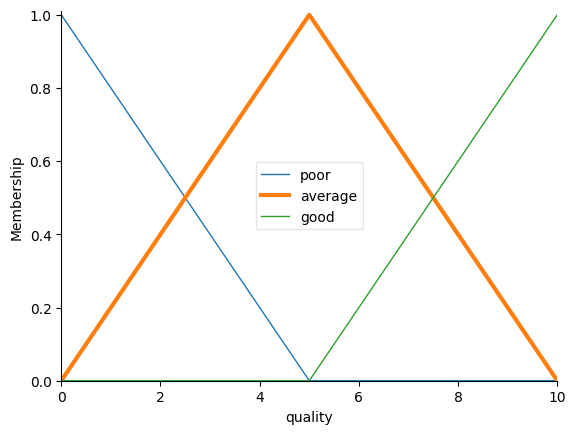

In [3]:
# To help understand what the membership looks like, use the view method.
quality['average'].view()

C:\Users\maril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


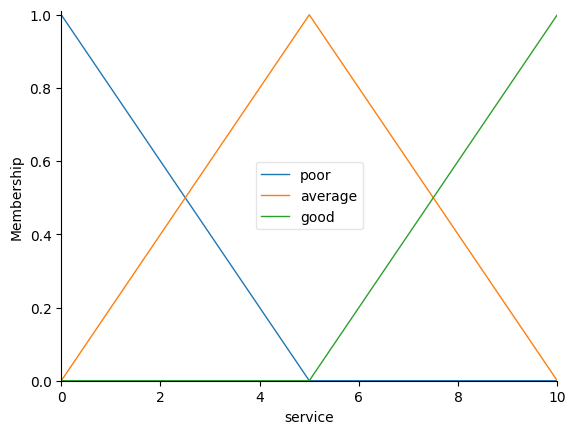

In [4]:
service.view()

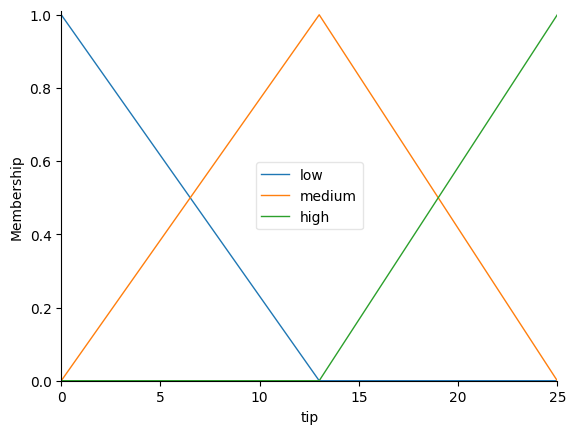

In [5]:
tip.view()

In [6]:
# Now, to make these triangles useful, we define the fuzzy relationship between input and output variables.
# For the purposes of our example, consider three simple rules:
# 1. If the food is poor OR the service is poor, then the tip will be low
# 2. If the service is average, then the tip will be medium
# 3. If the food is good OR the service is good, then the tip will be high

rule1 = ctrl.Rule(quality['poor'] | service['poor'], tip['low'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['good'] | quality['good'], tip['high'])

In [7]:
# Now that we have our rules defined, we can simply create a control system via:
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])

In [8]:
# In order to simulate this control system, we will create a ControlSystemSimulation.
# Think of this object representing our controller applied to a specific set of circumstances.
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

In [9]:
# We can now simulate our control system by simply specifying the inputs and calling the compute method.
# Pass inputs to the ControlSystem using Antecedent labels with Pythonic API
# Note: if you like passing many inputs all at once, use .inputs(dict_of_data)
tipping.input['quality'] = 6.5
tipping.input['service'] = 9.8

# Crunch the numbers
tipping.compute()

19.847607361963192


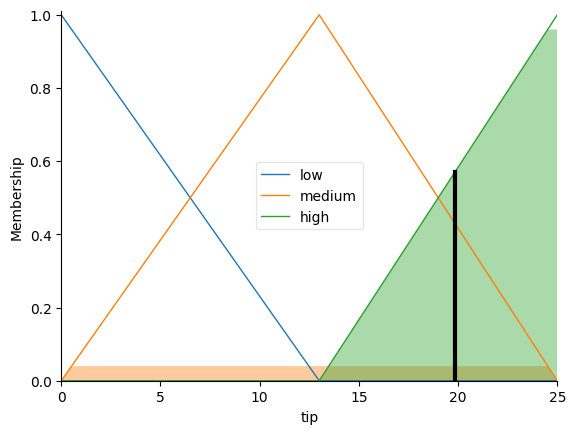

In [10]:
# Once computed, we can view the result as well as visualize it.
print(tipping.output['tip'])
tip.view(sim=tipping)

## **Part B - A PD fuzzy controller (a nonlinear controller)**
Code based on [this content](https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_control_system_advanced.html#example-plot-control-system-advanced-py)

In [11]:
# Sparse universe makes calculations faster, without sacrifice accuracy.
# Only the critical points are included here; making it higher resolution is
# unnecessary.
universe = np.linspace(-2, 2, 5)

# Create the three fuzzy variables - two inputs, one output
error = ctrl.Antecedent(universe, 'error')
delta = ctrl.Antecedent(universe, 'delta')
output = ctrl.Consequent(universe, 'output')

# Here we use the convenience `automf` to populate the fuzzy variables with
# terms. The optional kwarg `names=` lets us specify the names of our Terms.
names = ['nb', 'ns', 'ze', 'ps', 'pb']
error.automf(names=names)
delta.automf(names=names)
output.automf(names=names)

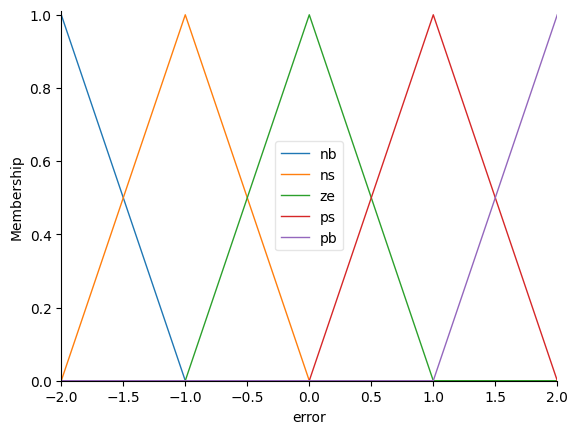

In [12]:
error.view()

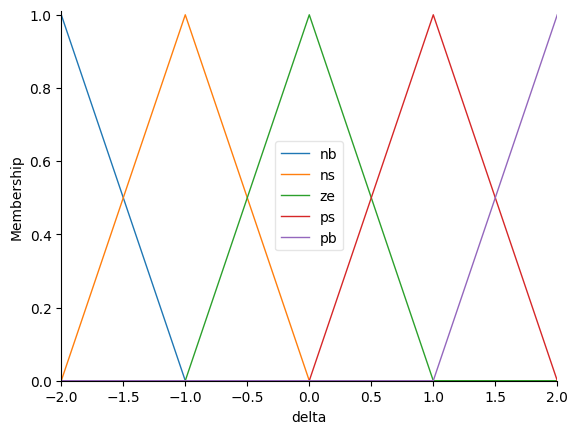

In [13]:
delta.view()

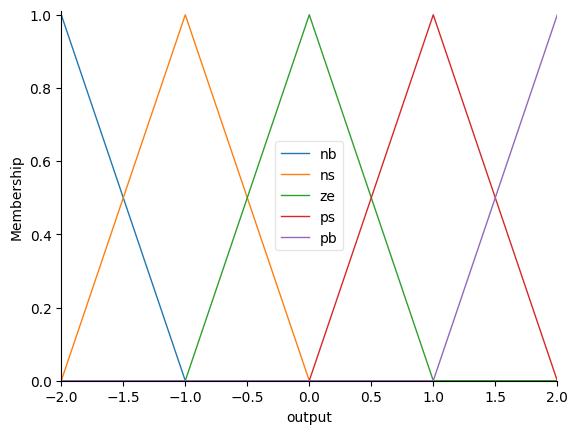

In [14]:
output.view()

In [15]:
rule0 = ctrl.Rule(antecedent=((error['nb'] & delta['nb']) |
                              (error['ns'] & delta['nb']) |
                              (error['nb'] & delta['ns'])),
                  consequent=output['pb'], label='rule pb')

rule1 = ctrl.Rule(antecedent=((error['nb'] & delta['ze']) |
                              (error['nb'] & delta['ps']) |
                              (error['ns'] & delta['ns']) |
                              (error['ns'] & delta['ze']) |
                              (error['ze'] & delta['ns']) |
                              (error['ze'] & delta['nb']) |
                              (error['ps'] & delta['nb'])),
                  consequent=output['ps'], label='rule ps')

rule2 = ctrl.Rule(antecedent=((error['nb'] & delta['pb']) |
                              (error['ns'] & delta['ps']) |
                              (error['ze'] & delta['ze']) |
                              (error['ps'] & delta['ns']) |
                              (error['pb'] & delta['nb'])),
                  consequent=output['ze'], label='rule ze')

rule3 = ctrl.Rule(antecedent=((error['ns'] & delta['pb']) |
                              (error['ze'] & delta['pb']) |
                              (error['ze'] & delta['ps']) |
                              (error['ps'] & delta['ps']) |
                              (error['ps'] & delta['ze']) |
                              (error['pb'] & delta['ze']) |
                              (error['pb'] & delta['ns'])),
                  consequent=output['ns'], label='rule ns')

rule4 = ctrl.Rule(antecedent=((error['ps'] & delta['pb']) |
                              (error['pb'] & delta['pb']) |
                              (error['pb'] & delta['ps'])),
                  consequent=output['nb'], label='rule nb')

In [16]:
system = ctrl.ControlSystem(rules=[rule0, rule1, rule2, rule3, rule4])

# Later we intend to run this system with a 21*21 set of inputs, so we allow
# that many plus one unique runs before results are flushed.
# Subsequent runs would return in 1/8 the time!
sim = ctrl.ControlSystemSimulation(system, flush_after_run=21 * 21 + 1)

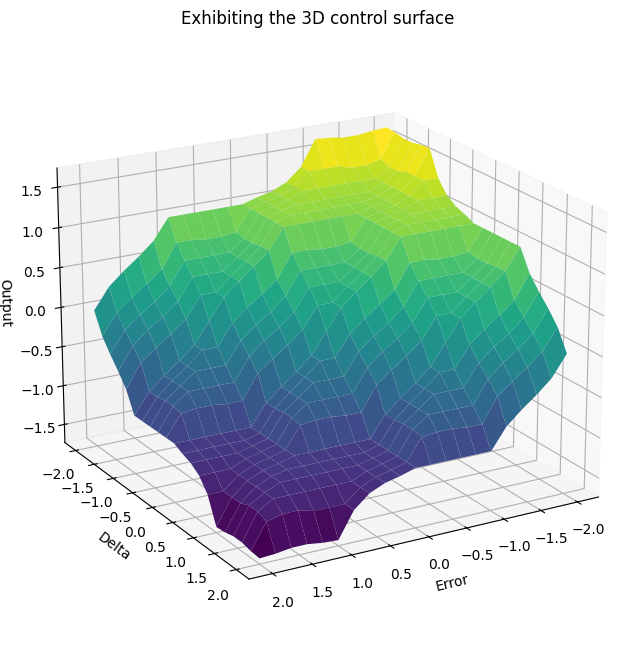

In [17]:
# We can simulate at higher resolution with full accuracy
upsampled = np.linspace(-2, 2, 21)
x, y = np.meshgrid(upsampled, upsampled)
z = np.zeros_like(x)

# Loop through the system 21*21 times to collect the control surface
for i in range(21):
    for j in range(21):
        sim.input['error'] = x[i, j]
        sim.input['delta'] = y[i, j]
        sim.compute()
        z[i, j] = sim.output['output']

# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

plt.title('Exhibiting the 3D control surface')
ax.set_zlabel('Output')
ax.set_ylabel('Delta')
ax.set_xlabel('Error')

ax.view_init(20, 60)
plt.show()

<font color="green">
Atividade final <br>
Quais são as principais diferenças entre o controlador PD implementado acima e um controlador PD clássico, implementado em vários experimentos anteriores deste curso?
</font>

Resposta:
As principais diferenças entre o controlador PD fuzzy implementado no experimento e um controlador PD clássico estão associadas principalmente à natureza da resposta do sistema e na forma como o sinal de controle é calculado. Enquanto um controlador PD clássico opera através da combinação linear dos ganhos sobre o erro e sua derivada, o controlador PD fuzzy abordado neste experimento utiliza um sistema baseado em lógica difusa, isto é, o modelo aplica graus de pertinência em uma lógica multivalorada (ou difusa), introduzindo níveis que variam continuamente entre 0 e 1 e que é capaz de lidar com incertezas. Nesse caso, as entradas de "erro" e "delta" são processadas por meio de funções de pertinência predefinidas com rótulos linguísticos como 'nb', 'ns', 'ze', 'ps' e 'pb'.

No código, observa-se que o comportamento do sistema é determinado por um conjunto de regras específicas que mapeiam essas entradas para a saída, o que substitui a necessidade de uma equação linear. Essa estrutura faz com que o controlador apresente uma característica não-linear, o que fica evidente na superfície de controle tridimensional gerada pela simulação. Esse comportamento se difere daquele visto no controlador PD linear tradicional, pois permite que o sistema apresente respostas mais flexíveis e adaptativas em diferentes regiões de operação, algo que um controlador linear com ganhos estáticos não conseguiria reproduzir da mesma maneira.